In [1]:
#Inicialización: borra todo y carga librerías (se pueden instalar fácilmente si no las tienen):
# install.packages("libreríaquequiero")

#Borra consola, variables y funciones definidas en el entorno Global
rm(list = setdiff(ls(), lsf.str()));
rm(list=lsf.str());
cat("\014")

#librerías, temas
suppressMessages(library("crayon")); suppressMessages(library("ggplot2"));
suppressMessages(library("gridExtra"));suppressMessages(library("latex2exp"))
library(xtable)
library(IRdisplay)
library(repr)

#opciones de ploteo ggplot2
temajuan3 <- theme(
    legend.title = element_text(size = 14),
    panel.background = element_rect(fill = "gray93"),
    legend.box = "vertical",
    legend.direction = "vertical",
    legend.key.height = unit(0.1,"snpc"),
    legend.key.width  = unit(0.1,"snpc"),
    axis.line = element_line(size = 0.5, lineend = "square"),
    axis.ticks = element_line(size = 1, colour = "black"),
    panel.border = element_rect(size = 1, fill = NA ),
    axis.title = element_text(size = 24),
    axis.text.x  = element_text(size = 20),
    axis.text.y = element_text(size = 20),
    legend.background = element_blank(),
    legend.position = c(0.3,0.8),
    legend.key = element_blank(),
    legend.text = element_text(size = 20),
    plot.title = element_text(size = 24)
    )
source("/home/juan/Documentos/Rfunj/temajuan2.R")
fig <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
 }
setwd("/home/juan/Documentos/Docencia/fexpi/")


Attaching package: ‘IRdisplay’


The following object is masked from ‘package:xtable’:

    display




### Alguna digresión sobre la media muestral $\bar{x}$

* Los valores no están ordenados, es decir, no se aprecia alguna relación entre $n_i$ y $n_{i+1}$.Lo que sí se puede observar es cómo los puntos tienden a reunirse en una ***línea*** al centro.


* Vemos que la media no esta muy lejos del valor central (esta en la misma clase) pero podría estimarlo mejor.


* "Es erróneo elegir una medida por encima de las demás dado que todas se realizaron bajo condiciones idénticas. Lo ideal sería calcular la media muestral y usarla como nuestra mejor aproximación al modelo, o, mejor dicho, nuestra medida más “fiable”."

## Recordando:

+ Las medidas en general, tienen ruidos, y si medimos varias veces la misma cantidad (salvo cosas gruesas), tenemos una colección de valores.

+ Los ruidos los modelamos con la idea de azar (*azahar*), por lo que debemos corroborar de qué distribución salen los ruidos (acá sólo vimos dist. normales)

   + Nos deshacemos de los ruidos usando la **media muestral** $\overline{x}$
   
   + La media muestral es una ***aproximación*** de la media teórica, $\mu$ 


# Una cuestión de tamaño de muestra

Medimos el acelerómetro del teléfono en reposo $N = 5$ veces. Luego hacemos la misma medida $N = 1000$.

In [ ]:
a5 <- rnorm(mean = 9.8, sd = 0.2, n = 5); a1000 <- rnorm(mean = 9.8, sd = 0.2, n = 1000);


#### Media: Definición:

La media de una distribución cualquiera (el primer momento de una distribución) se define como:

$$
\mu = \int_{-\infty}^\infty x f(x) dx \\
\mu = \sum x p(x)
$$
La cosa es cómo relacionar esto con la $f(x)$ ó la $p(x)$.

Recordemos: $$p(x) = \lim_{n \rightarrow \infty} \; \; \; n_x/n$$.

Y el infinito no llega nunca.



#### Media muestral: una cuenta naïve

$$
\overline{x} = \sum_{i = 1}^n \frac{x_i}{n} = \frac{x_1 + x_2 + ... + x_n}{n}
$$

Pensemos en que algunas $x_i$ se "repiten" un número $n_i$ de veces: 
$$
\overline{x} = \frac{x_1 + x_2 + ... + x_n}{n} = \sum_{n = 1}^{N} \frac{x_i n_i}{N} =\sum_{n = 1}^{N} x_i \frac{n_i}{N}
$$

Si hacemos que $N \rightarrow \infty$....
$$
\overline{x}_{N \rightarrow \infty} \; = \;\; \sum_{n = 1}^{N \rightarrow  \infty} \; \; x_i \;\; \overbrace{\frac{n_i}{N}}^{p(x)} \; \; =  \;\mu
$$



#### De lo anterior:

+ La media muestral $\overline{x}$, en general, es una media que no converge a $\mu$, porque la armamos con una cantidad finita de casos.


### Desviación estándar: Definición
$$
\begin{split}
\sigma_X &=\sqrt{ \langle (X - \mu)^2 \rangle = }\\
           &=\sqrt{ \langle X^2 \rangle - \langle X \rangle ^2 = }\\
           &=\sqrt{ \sum_{i = 1}^{\infty} x_i^2 p(x_i) - \Bigg(\sum_{i = 1}^{\infty}x_ip(x_i)\Bigg)^2 }
\end{split}
$$

Ya odiamos a $p(x_i)$. No tenemos infinitos casos.

### Desviación estándar de la muestra

$$
\sigma =\sqrt{ \sum_{i = 1}^{\infty} x_i^2 p(x_i) - \Bigg(\sum_{i = 1}^{\infty}x_ip(x_i)\Bigg)^2 }
$$

* Chau infinito, reemplazamos el segundo término por la media muestral. n pasa a $n-1$ porque al calcular la media muestral le sacamos un grado de libertad a nuestro conjuntito de datos.

$$
s = \sqrt{ \sum_{i = 1}^{n}\frac{\big(x_i^2  - \overline{x}\big)^2 }{n-1}}
$$

La desviación estándar de la muestra 

### Vemos que:

* Estas cantidades ***estiman*** el primer momento y el primer momento centrado de una distribución ***cualquiera***. Hay un problema con $n$ que luego veremos cómo resolver, por ahora, estiman sin cota de confianza.

* Si los datos están muy sucios, la media y la desviación estándar de la muestra, no estiman lo que queremos que estimen: la media muestral no estima nuestra medida, y la desviación estándar generalmente, crece demasiado. Limpiar datos es de gente de bien, limpiar demasiado es de mentirosos. 



***La idea de muestreo*** implica que, cuando medimos, sale un histograma que no puede tener que ver con la distribución (sobre todo si medimos porcas veces) 

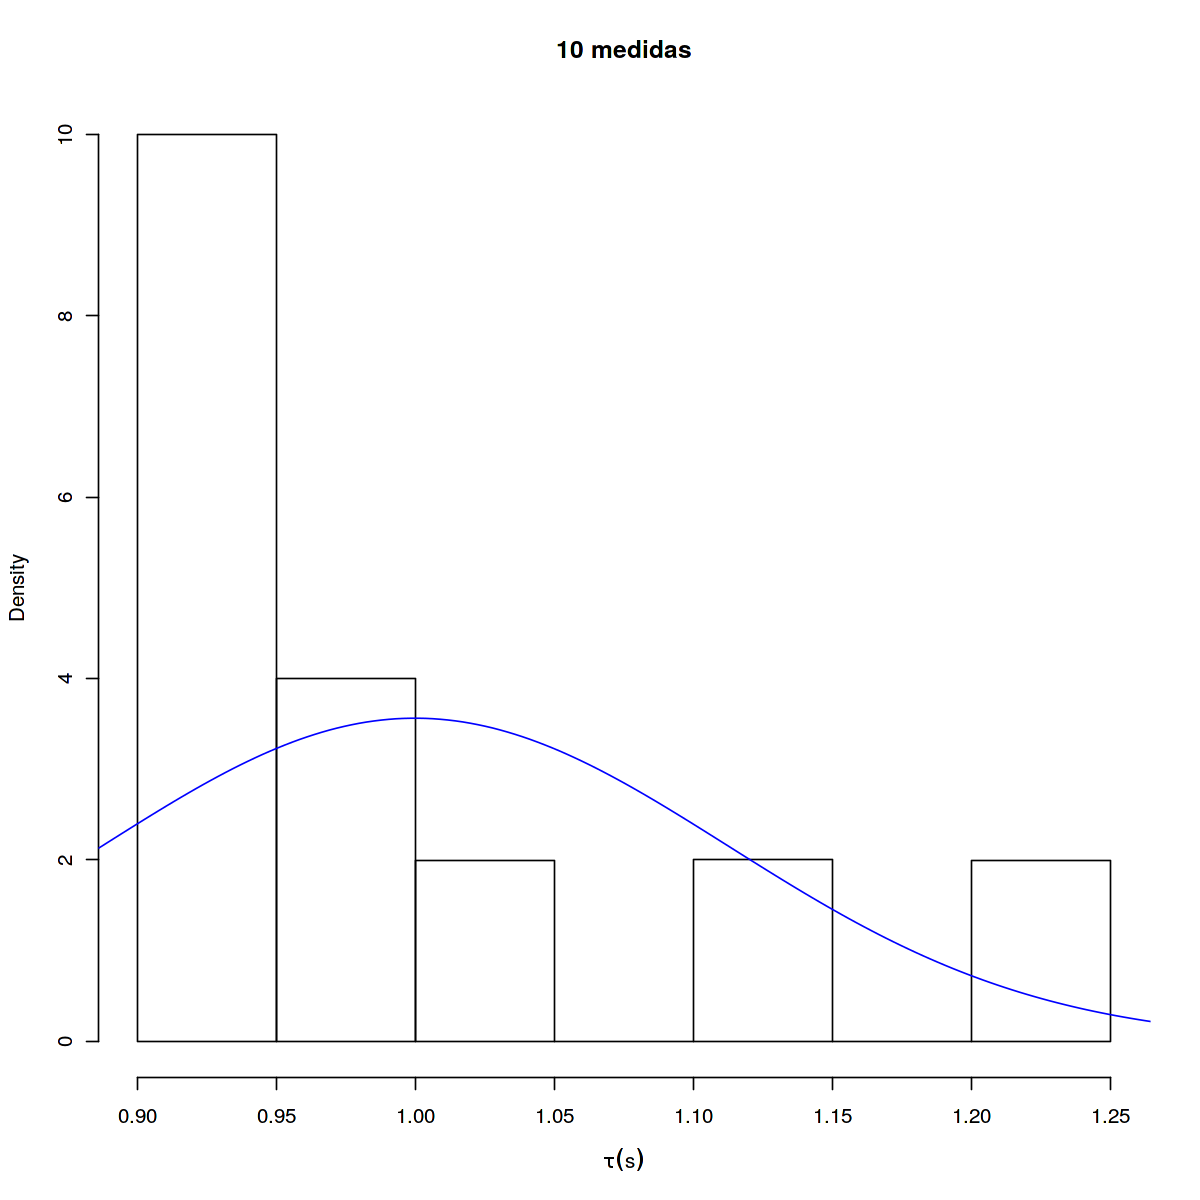

In [31]:
fig(10,10);periodo = 1;set.seed(10953); medidas <- rnorm(n = 10, mean = periodo, sd = 0.1);hist(medidas, breaks = nclass.FD(medidas)+1, xlab = expression(tau (s)), main = "10 medidas", prob = T)
lines(density(rnorm(n = 10^6, mean = periodo, sd=0.1), bw = 0.05), col = "Blue")

Claro que si medimos $n = 10^6$, todo parece *fermoso*:

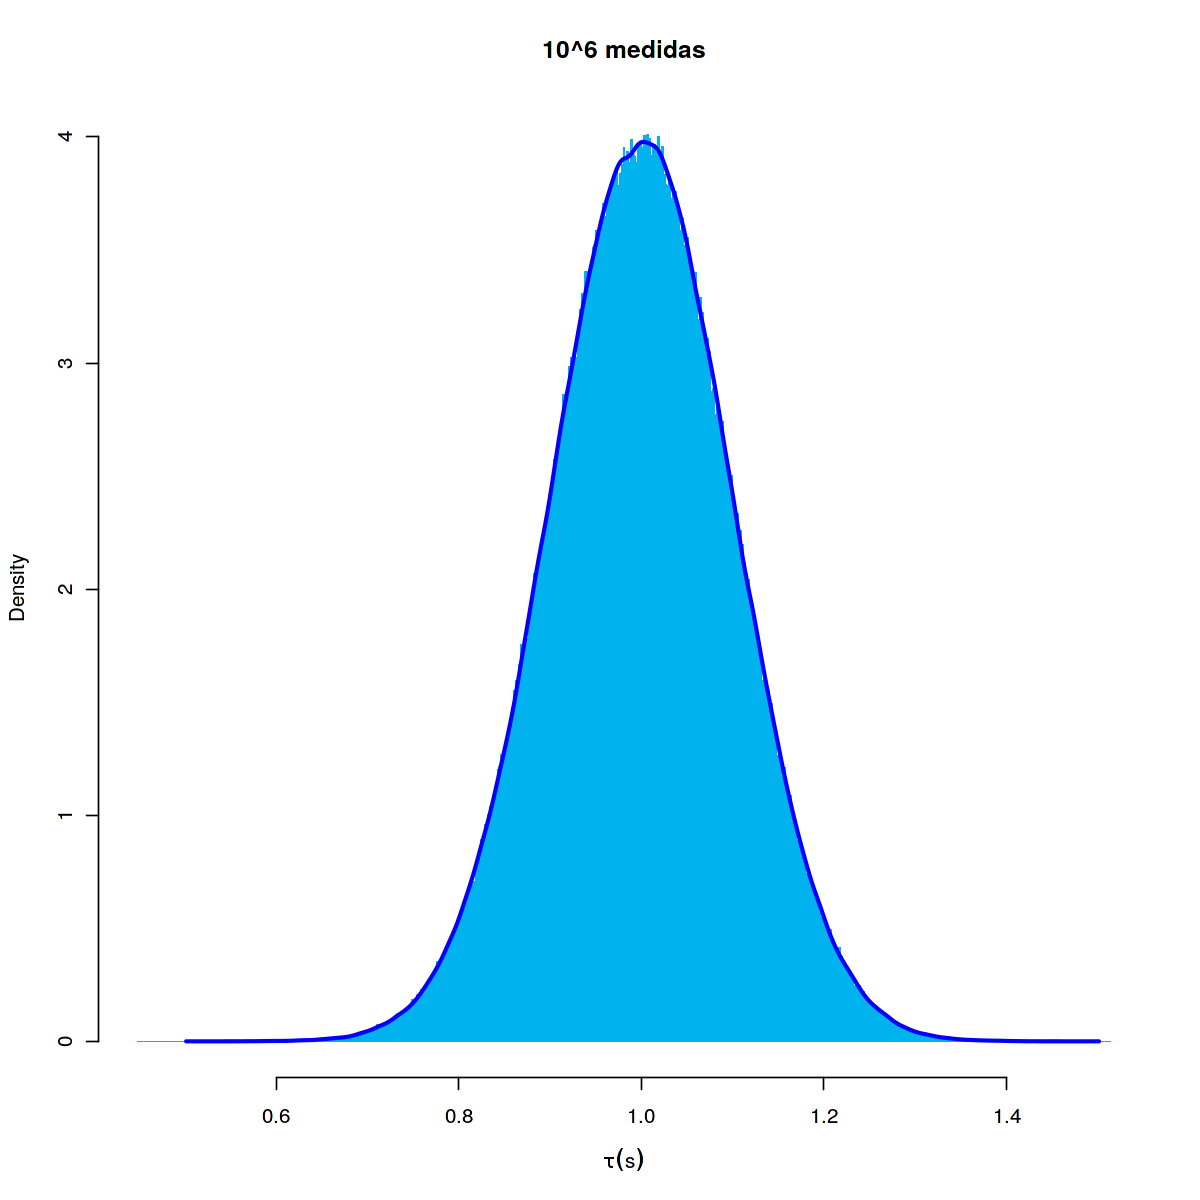

In [33]:
fig(10,10);periodo = 1;set.seed(10953); medidas <- rnorm(n = 10^6, mean = periodo, sd = 0.1);hist(medidas, breaks = nclass.FD(medidas)+1, xlab = expression(tau (s)), main = "10^6 medidas", prob = T, border = NA, col = "Deepskyblue2")
lines(density(rnorm(n = 10^6, mean = periodo, sd=0.1)), col = "Blue", lwd = 2.5)

#### 1. Teorema del Límite Central
**Teorema (una de las versiones sin demostración)**
$$X_1 -> \text{medir...} -> x_1 \text{(un valor)} $$
Sean $X_1, X_2, X_3,.., X_N$, N variables aleatorias ***independientes e idénticamente distribuídas*** (IID), con distribuciones de probabilidad ***inespecificadas***, con media $\mu$ y varianza $\sigma^2$.

Entonces la media de la muestra $$\bar{X} =  \sum_{i = 1}^{N} X_i / N$$

tiene una distribución con media $\mu$ y varianza $\sigma^2/N$, que se aproxima a una gaussiana a medida que $N\rightarrow \infty$

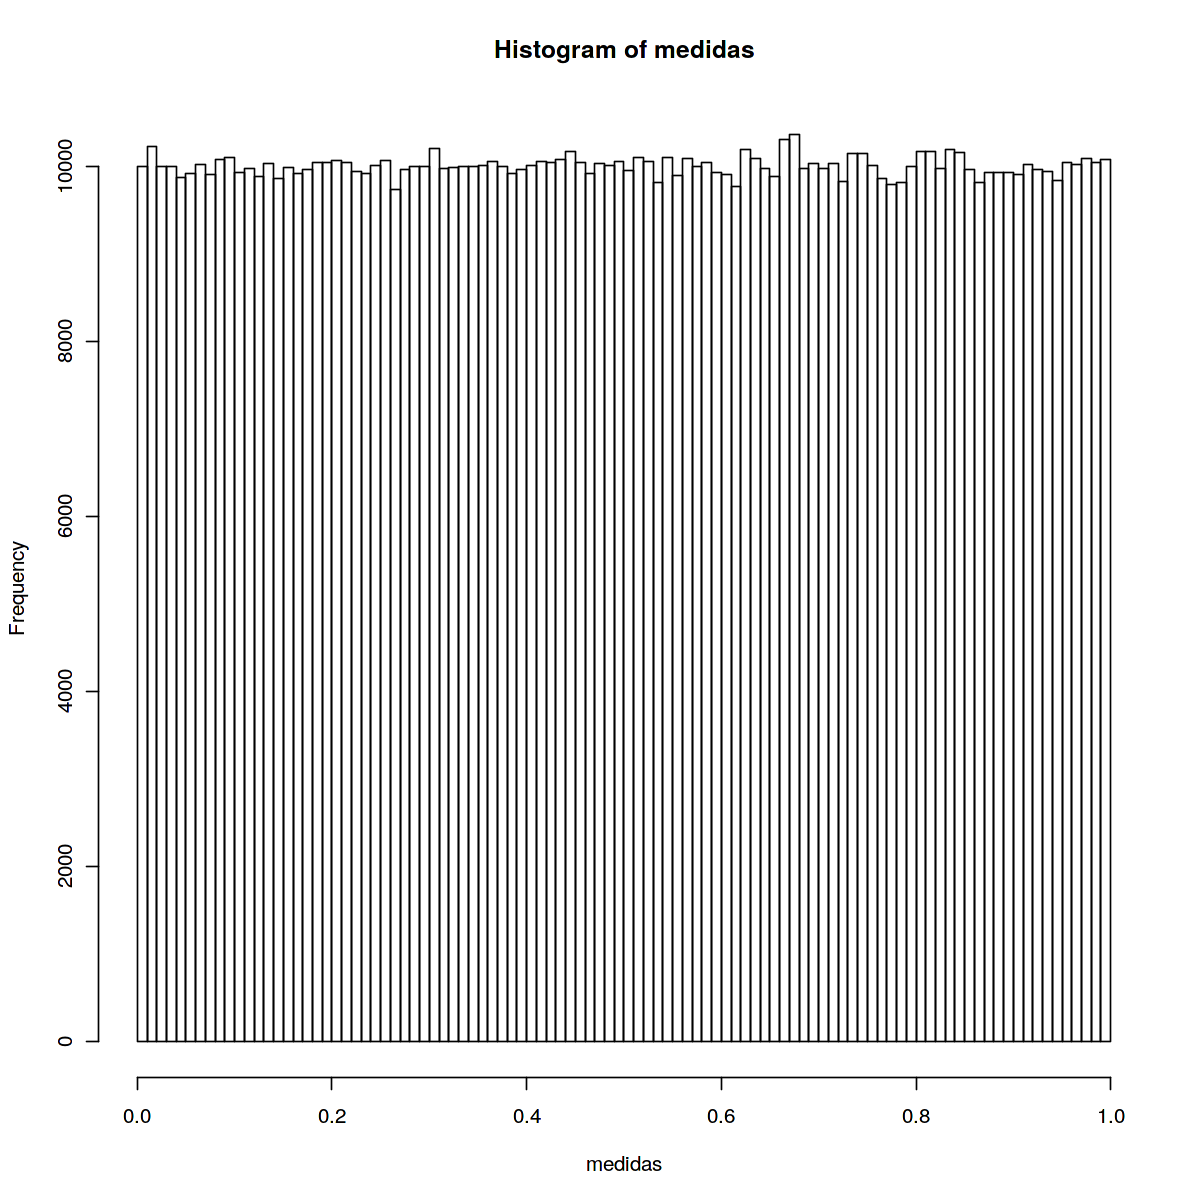

In [24]:
medidas <- runif(10^6); hist(medidas, breaks =nclass.FD(medidas))

Sampleamos de a dos en dos:

mm.3 <- vector(mode = "numeric", length = 10^4)
for(i in 1:10^5){mm.2[i] <- mean(sample(medidas, 2))}
hist(mm.2, breaks = nclass.FD(mm.2))

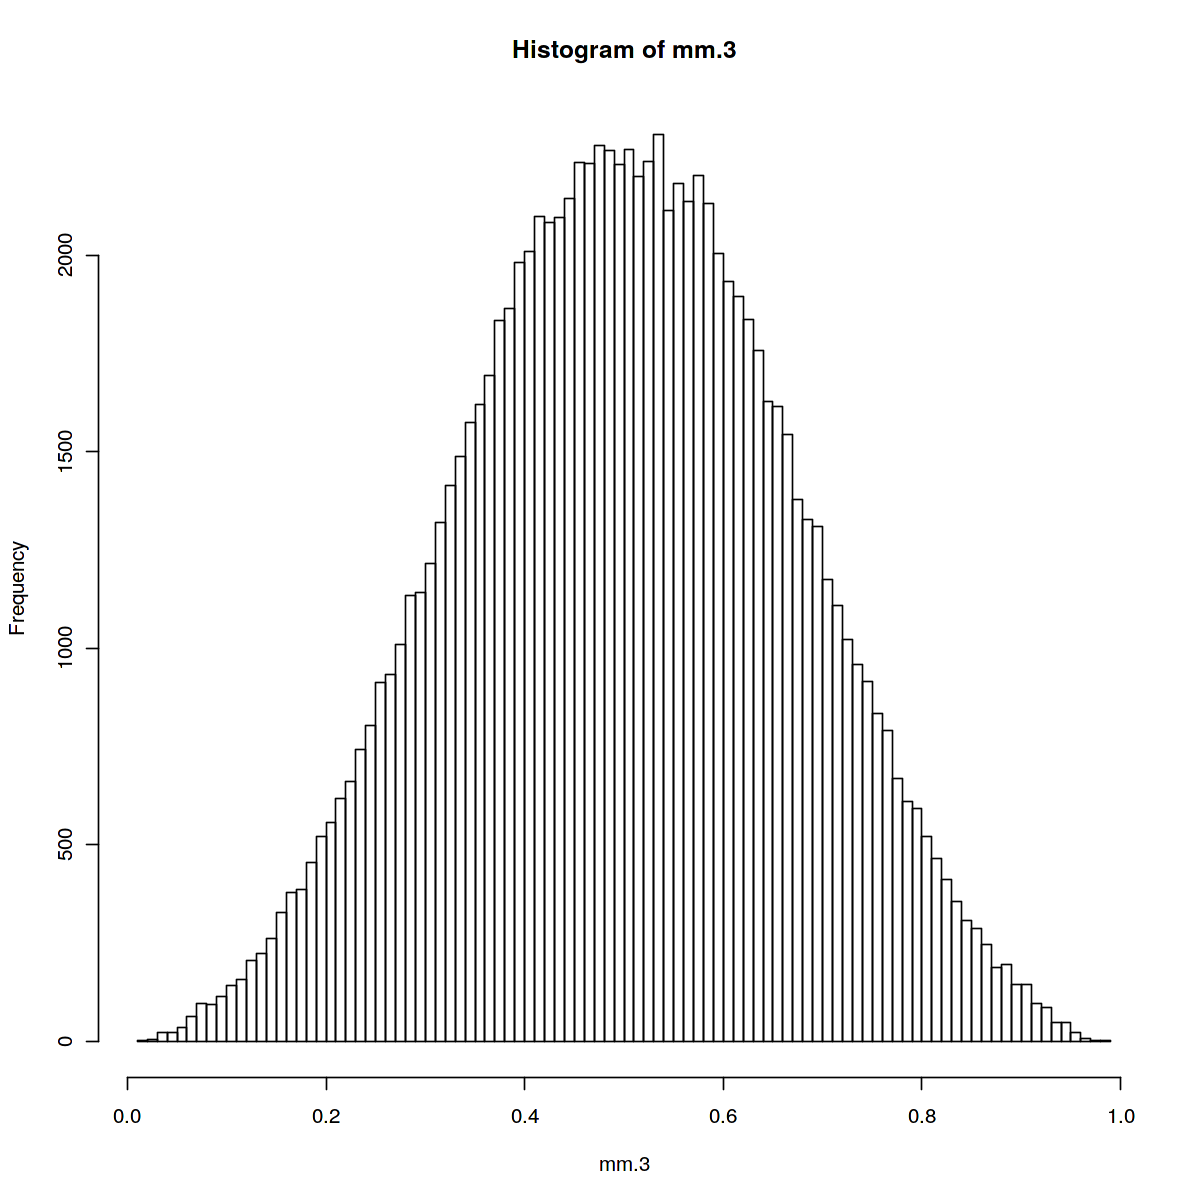

In [28]:
mm.3 <- vector(mode = "numeric", length = 10^5)
for(i in 1:10^5){mm.3[i] <- mean(sample(medidas, size = 3, replace = T))}
hist(mm.3, breaks = nclass.FD(mm.3))

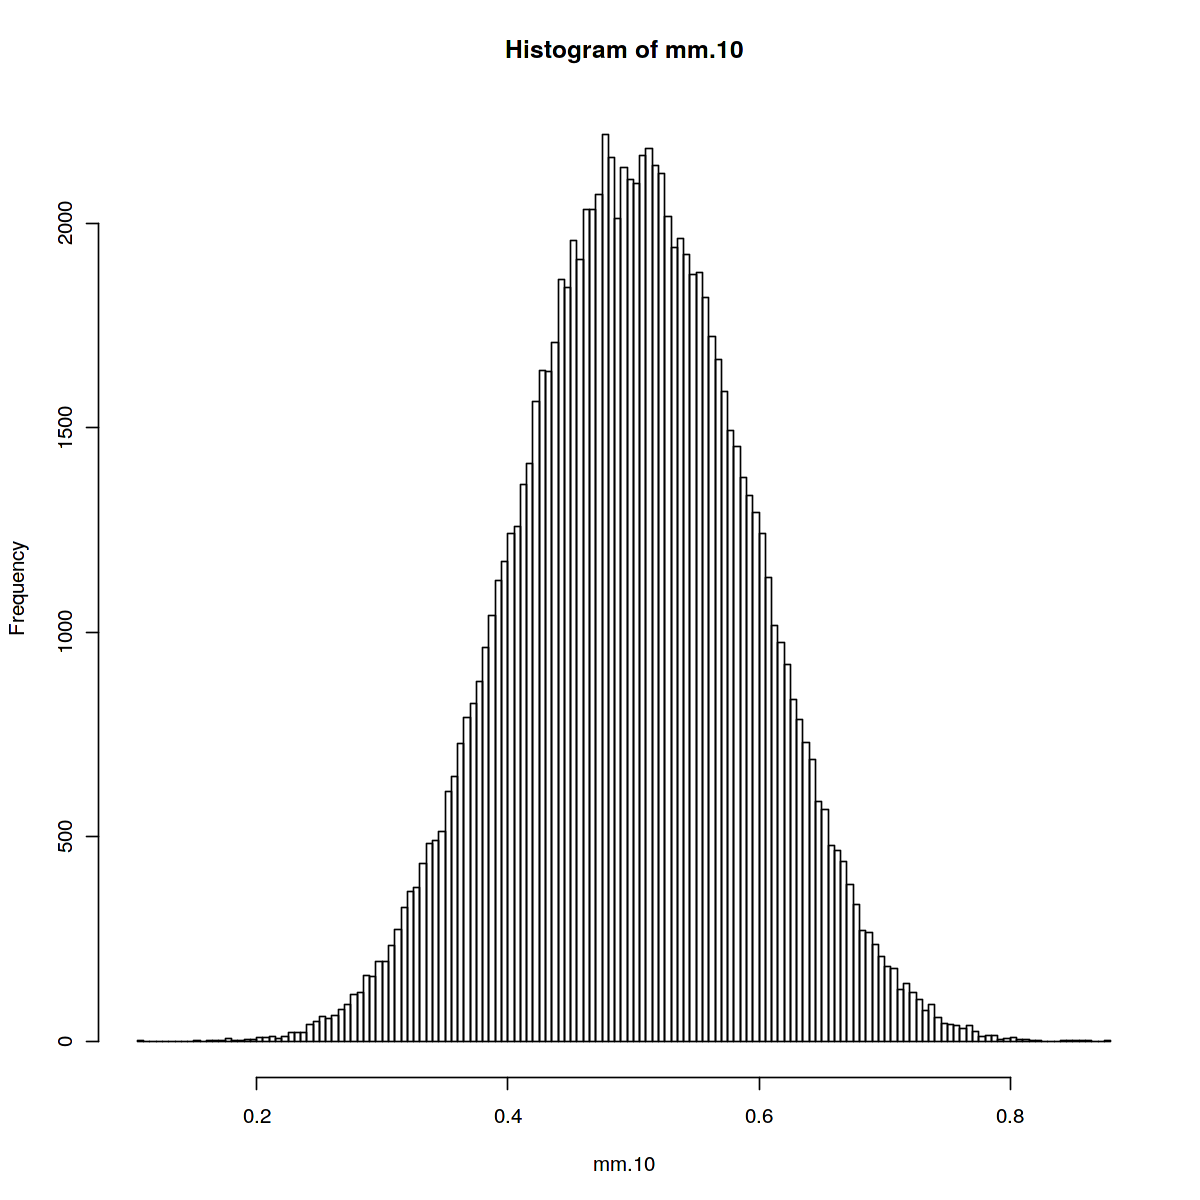

In [29]:
mm.10 <- vector(mode = "numeric", length = 10^5)
for(i in 1:10^5){mm.10[i] <- mean(sample(medidas, size = 10, replace = T))}
hist(mm.10, breaks = nclass.FD(mm.10))

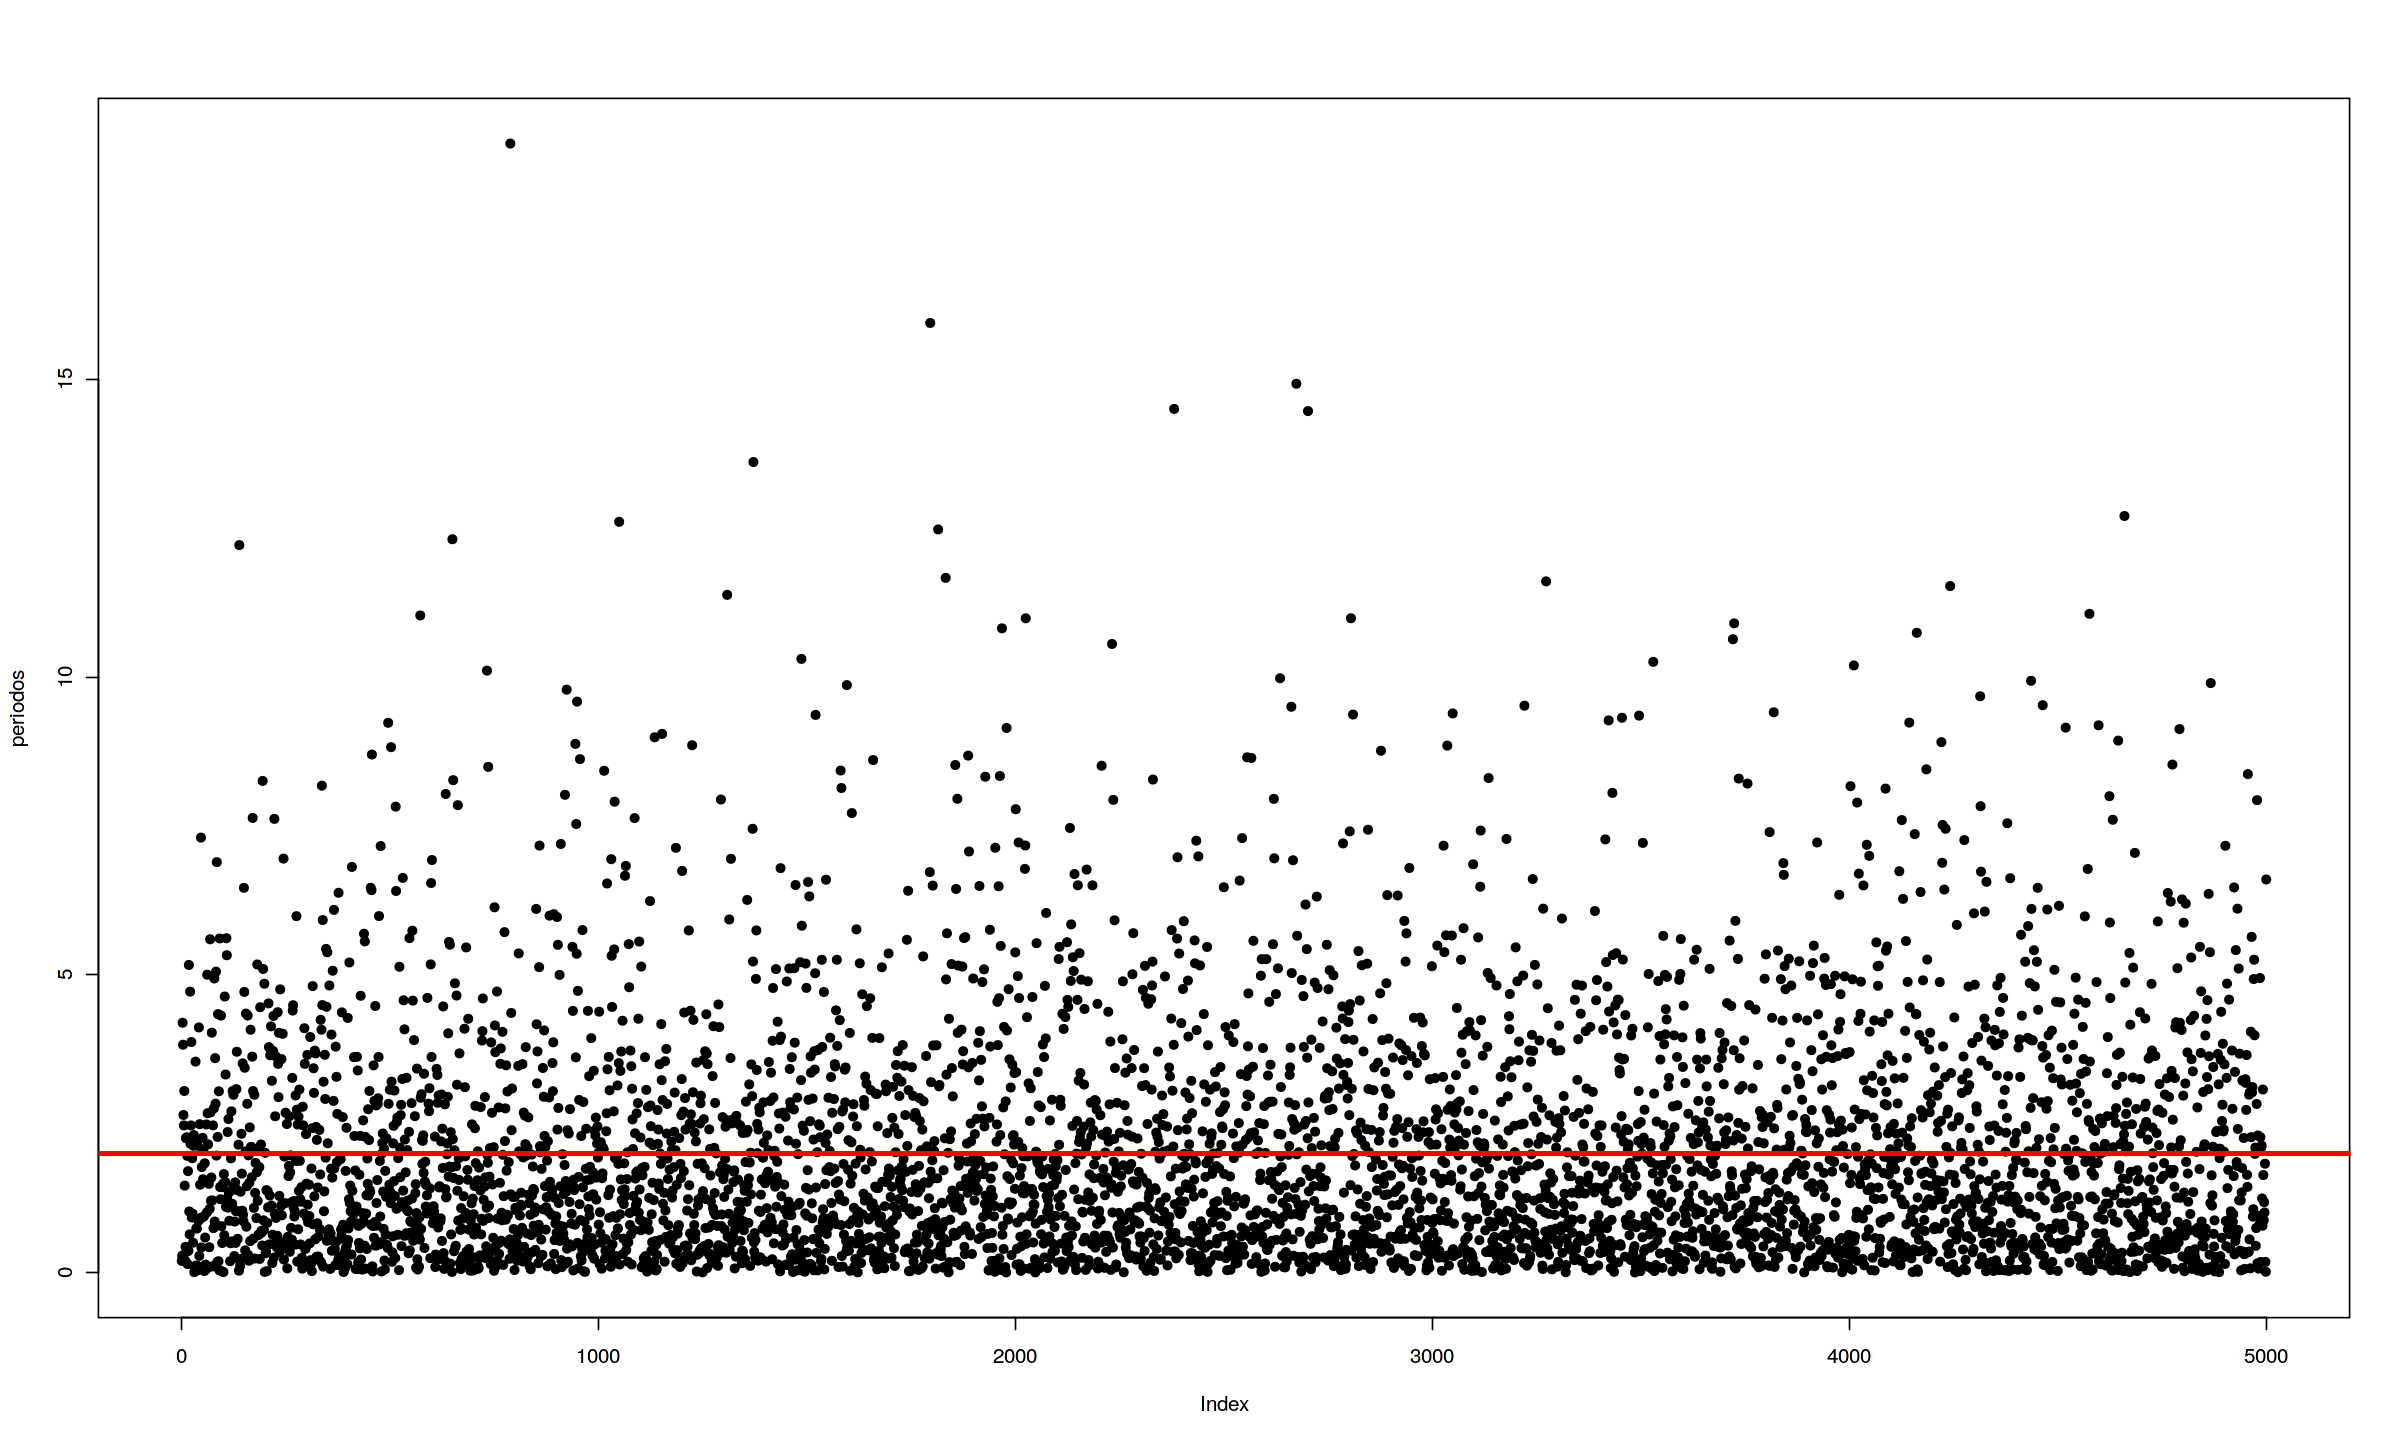

In [46]:
periodos <- rexp(n = 5000, rate = 0.5 ); fig(20,12);#plot(periodos, pch = 16, cex = 1);
abline(h = mean(periodos), col = "Red", lwd = 3);